In [34]:
import numpy as np
import pandas as pd
import pymc as pm
import numpy as np
import pandas as pd
import arviz as az
import xarray as xr
import pytensor.tensor as pt
from pytensor.scan.basic import scan
from scipy.stats import kstest
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from IPython.display import Latex, display
from pathlib import Path
import matplotlib.pyplot as plt
import os

In [2]:
OUT = Path("figs"); OUT.mkdir(exist_ok=True)

In [3]:
file_path = 'bitcoin_blocks_and_transactions_sorted.csv'
pd.set_option('display.max_columns', None)
df = pd.read_csv(file_path,index_col=False)
num_rows = df.shape[0]
print(f"Number of rows using .shape[0]: {num_rows}")

Number of rows using .shape[0]: 15000


In [4]:
df.head()

,id,height,version,timestamp,tx_count,size,weight,merkle_root,previousblockhash,mediantime,nonce,bits,difficulty,total_trans_fees,input_count,output_count,input_value
0,00000000000000000001c827e4d9c2360756e5d76e492b...,862501,603979776,1727084204,2277,1856961,3992901,17d01c5d7b8441565de2ccf4db0e8163403b0899007f07...,00000000000000000002d5b4f115ca2458acb75a13422e...,1727081265,978191335,386075020,9.267158e+13,4271007,10932.0,1.021110e+11,1.017980e+11
1,0000000000000000000165f7b6a0c0ef25ea3cae79c865...,862502,738197504,1727084749,2341,1839000,3993360,47ed70e4da0f302114fc572bab062c99c0bbe3070fd315...,00000000000000000001c827e4d9c2360756e5d76e492b...,1727082238,827544669,386075020,9.267158e+13,4302041,10719.0,7.759630e+11,7.756510e+11
2,00000000000000000001a519c445c0a3f1319630603560...,862503,823279616,1727085461,3137,1645376,3993413,eeff8b0b686006f32aedbe7d4c0eaaa321b6fd73c8c723...,0000000000000000000165f7b6a0c0ef25ea3cae79c865...,1727082320,871041503,386075020,9.267158e+13,5259048,8704.0,1.899960e+11,1.896830e+11
3,000000000000000000020bce365f1f28bc4d51779fdb02...,862504,536911872,1727086363,3447,1716979,3993739,dc16c1f3d16552542d1a10894dbcc7fda6464ea7f3f055...,00000000000000000001a519c445c0a3f1319630603560...,1727082730,3106376116,386075020,9.267158e+13,5575404,8815.0,2.577620e+12,2.577300e+12
4,000000000000000000020a8002a7488358d0a7313a00c9...,862505,1073676288,1727087094,3360,1741490,3997772,e0450adca29bf1be837896b4ea3c8ad693079529bc80e2...,000000000000000000020bce365f1f28bc4d51779fdb02...,1727083818,610837269,386075020,9.267158e+13,5149822,8926.0,5.237330e+11,5.234210e+11


In [5]:
columns_to_drop = ['id','height', 'merkle_root','previousblockhash','mediantime']
df = df.drop(columns_to_drop, axis=1)

In [6]:
df.insert(0, 'formatted_timestamp', pd.to_datetime(df['timestamp'],unit='s'))

In [7]:
df= df.sort_values(by='formatted_timestamp', ascending=True)

In [8]:
delay_interval = round(pd.to_datetime(df['timestamp'],unit='s').diff().dt.total_seconds())
df.insert(0, 'delay_interval', delay_interval)

In [9]:
df.head()

,delay_interval,formatted_timestamp,version,timestamp,tx_count,size,weight,nonce,bits,difficulty,total_trans_fees,input_count,output_count,input_value
0,NaN,2024-09-23 09:36:44,603979776,1727084204,2277,1856961,3992901,978191335,386075020,9.267158e+13,4271007,10932.0,1.021110e+11,1.017980e+11
1,545.0,2024-09-23 09:45:49,738197504,1727084749,2341,1839000,3993360,827544669,386075020,9.267158e+13,4302041,10719.0,7.759630e+11,7.756510e+11
2,712.0,2024-09-23 09:57:41,823279616,1727085461,3137,1645376,3993413,871041503,386075020,9.267158e+13,5259048,8704.0,1.899960e+11,1.896830e+11
3,902.0,2024-09-23 10:12:43,536911872,1727086363,3447,1716979,3993739,3106376116,386075020,9.267158e+13,5575404,8815.0,2.577620e+12,2.577300e+12
4,731.0,2024-09-23 10:24:54,1073676288,1727087094,3360,1741490,3997772,610837269,386075020,9.267158e+13,5149822,8926.0,5.237330e+11,5.234210e+11


In [10]:
df.iat[0, 0] = 0
df['difficulty'] = pd.to_numeric(df['difficulty'], errors='coerce')

In [11]:
 df.head()

,delay_interval,formatted_timestamp,version,timestamp,tx_count,size,weight,nonce,bits,difficulty,total_trans_fees,input_count,output_count,input_value
0,0.0,2024-09-23 09:36:44,603979776,1727084204,2277,1856961,3992901,978191335,386075020,9.267158e+13,4271007,10932.0,1.021110e+11,1.017980e+11
1,545.0,2024-09-23 09:45:49,738197504,1727084749,2341,1839000,3993360,827544669,386075020,9.267158e+13,4302041,10719.0,7.759630e+11,7.756510e+11
2,712.0,2024-09-23 09:57:41,823279616,1727085461,3137,1645376,3993413,871041503,386075020,9.267158e+13,5259048,8704.0,1.899960e+11,1.896830e+11
3,902.0,2024-09-23 10:12:43,536911872,1727086363,3447,1716979,3993739,3106376116,386075020,9.267158e+13,5575404,8815.0,2.577620e+12,2.577300e+12
4,731.0,2024-09-23 10:24:54,1073676288,1727087094,3360,1741490,3997772,610837269,386075020,9.267158e+13,5149822,8926.0,5.237330e+11,5.234210e+11


In [20]:
# ---- perf hygiene (do this before heavy imports) ----
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"


from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    brier_score_loss, log_loss
)

# Optional: numba speeds up Hawkes state recursion by ~10-50x
try:
    from numba import njit
except Exception:
    def njit(*args, **kwargs):
        def wrap(f): return f
        return wrap

# -------------------- shared helpers --------------------
def flatten_draws(da: xr.DataArray) -> np.ndarray:
    """(chain, draw, ...) -> (ndraws, ...)"""
    arr = np.asarray(da)
    if arr.ndim >= 2:
        return arr.reshape(arr.shape[0]*arr.shape[1], *arr.shape[2:])
    return arr

def thin_rows(arr: np.ndarray, max_rows: int = 600) -> np.ndarray:
    """Keep at most max_rows rows from arr (ndraws x ...)."""
    arr = np.asarray(arr)
    if arr.shape[0] <= max_rows:
        return arr
    step = int(np.ceil(arr.shape[0] / max_rows))
    return arr[::step][:max_rows]

def get_var(idata, *candidates):
    """Return the first posterior var that exists."""
    for nm in candidates:
        if nm in idata.posterior.data_vars:
            return nm
    raise KeyError(f"None of {candidates} found in posterior vars: {list(idata.posterior.data_vars)}")

def ensure_ll(idata: az.InferenceData, varname: str = "interval") -> az.InferenceData:
    """Make sure idata.log_likelihood[varname] exists."""
    if hasattr(idata, "log_likelihood") and varname in idata.log_likelihood.data_vars:
        return idata
    if hasattr(idata, "log_likelihood") and len(idata.log_likelihood.data_vars) > 0:
        # alias first LL to requested name without copying data
        key = list(idata.log_likelihood.data_vars)[0]
        ll  = idata.log_likelihood[key]
        new = idata.copy()
        new.add_groups({"log_likelihood": {varname: ll}})
        return new
    if hasattr(idata, "posterior") and "ll_interval" in idata.posterior.data_vars:
        ll  = idata.posterior["ll_interval"]
        new = idata.copy()
        new.add_groups({"log_likelihood": {varname: ll}})
        return new
    raise ValueError("No log_likelihood present; fit models with observed likelihoods or add ll_interval.")


In [21]:
def prepare_times_and_covars(df, covar_cols):
    """
    df: DataFrame with 'timestamp' (POSIX seconds) OR precomputed 'delay_interval' (seconds).
    covar_cols: list of columns to use as covariates (will be z-scored).
    Returns:
      times: strictly increasing event times (float64)
      dt:    gaps (N-1,)
      X:     covariate matrix aligned to gaps (N-1, p)
    """
    # 1) event times
    if "timestamp" in df.columns:
        times = np.sort(np.asarray(df["timestamp"], float))
    elif "formatted_timestamp" in df.columns:
        times = np.sort(pd.to_datetime(df["formatted_timestamp"]).astype("int64").to_numpy() / 1e9)
    else:
        # fallback: reconstruct from first time + cumulative delays if present
        if "delay_interval" in df.columns:
            gaps  = np.asarray(df["delay_interval"], float)
            times = np.cumsum(gaps)  # arbitrary origin is OK for Hawkes/IP likelihoods
        else:
            raise ValueError("Need 'timestamp', 'formatted_timestamp', or 'delay_interval' to build times_data.")
    times = times[np.isfinite(times)]
    times = np.unique(times)  # ensure strictly increasing
    if times.size < 2:
        raise ValueError("Not enough events to compute inter-arrival times.")

    # 2) gaps
    dt = np.diff(times)
    # fix any zero/negatives (rare; due to duplicates) with tiny eps
    med = np.nanmedian(dt) if np.isfinite(np.nanmedian(dt)) else 600.0
    eps = max(1e-9, 1e-6 * med)
    dt  = np.where(dt > 0, dt, eps).astype(np.float64)

    # 3) covariates aligned to the *start* of gap i
    X = None
    if covar_cols:
        X = df.loc[:len(times)-2, covar_cols].to_numpy(dtype=float, copy=True)  # take first N-1 rows
        # z-score robustly
        mu  = np.nanmedian(X, axis=0)
        mad = np.nanmedian(np.abs(X - mu), axis=0)
        mad = np.where(mad == 0, 1.0, mad)
        X   = (X - mu) / (1.4826 * mad)
        X   = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    return times.astype(np.float64), dt.astype(np.float64), X

# Example usage:
# covars = ["difficulty","tx_count","size","weight","input_count","total_trans_fees"]
# times, dt, X = prepare_times_and_covars(df, covars)


In [22]:
# -------------------- Poisson --------------------
def poisson_tail_probs(id_pois, taus):
    mu_name = get_var(id_pois, "mu", "lam", "lambda")
    mu_draws = thin_rows(flatten_draws(id_pois.posterior[mu_name])).astype(np.float64)
    taus = np.asarray(taus, float)
    S = np.exp(-np.clip(mu_draws[:, None] * taus[None, :], 0, 7e2))  # (nd, T)
    return S.mean(0)  # (T,)

# -------------------- Inhomogeneous Poisson (IP) --------------------
def detect_ip_coeffs(id_ip, p):
    names = list(id_ip.posterior.data_vars)
    beta0 = None
    bvec  = None
    scalars = []
    if "beta0" in names: beta0 = "beta0"
    # vector with feat dim wins
    for nm in names:
        da = id_ip.posterior[nm]
        if "feat" in da.dims and da.sizes["feat"] == p:
            bvec = nm
            break
    if bvec is None:
        scalars = [nm for nm in names if nm.startswith("b_") or nm.startswith("coef_") or nm in
                   ("b_diff","b_tx","b_size","b_weight","b_input","b_fees")]
    return beta0, bvec, scalars

def ip_tail_probs_per_event(id_ip, X, tau, max_draws=600):
    assert X is not None, "X required for IP model."
    p = X.shape[1]
    beta0_name, bvec_name, scalars = detect_ip_coeffs(id_ip, p)

    if beta0_name:
        beta0 = thin_rows(flatten_draws(id_ip.posterior[beta0_name]), max_rows=max_draws)
    else:
        # fallback: zeros (intercept absorbed into b·x if standardized)
        any_da = next(iter(id_ip.posterior.data_vars.values()))
        beta0  = np.zeros(flatten_draws(any_da).shape[0], dtype=float)
        beta0  = thin_rows(beta0, max_rows=max_draws)

    if bvec_name:
        b = thin_rows(flatten_draws(id_ip.posterior[bvec_name]), max_rows=max_draws)  # (nd,p)
    else:
        cols = scalars[:p]
        if not cols:
            raise ValueError("Could not locate IP coefficients; expose b (feat) or b_* scalars.")
        b = np.column_stack([flatten_draws(id_ip.posterior[c]) for c in cols])
        b = thin_rows(b, max_rows=max_draws)

    nd = min(len(beta0), b.shape[0])
    beta0 = beta0[:nd].astype(np.float64)
    b     = b[:nd, :].astype(np.float64)
    Xf    = np.asarray(X, np.float64)  # (N-1,p)

    lin = beta0[:, None] + b @ Xf.T             # (nd, N-1)
    lam = np.exp(np.clip(lin, -40, 40))
    S   = np.exp(-lam * float(tau))             # (nd, N-1)
    return S.mean(0).astype(np.float64)         # (N-1,)

# -------------------- Hawkes (exp kernel) --------------------
@njit(cache=True, fastmath=True)
def _hawkes_state_from_gaps(dt, beta):
    """Return s at start of each gap (length len(dt)); s[0]=0."""
    n = dt.size
    out = np.empty(n, np.float64)
    out[0] = 0.0
    if n > 1:
        for i in range(1, n):
            out[i] = np.exp(-beta * dt[i-1]) * (1.0 + out[i-1])
    return out

def hawkes_tail_probs_per_event(id_hawkes, times, tau, max_draws=500):
    mu_d   = thin_rows(flatten_draws(id_hawkes.posterior[get_var(id_hawkes,"mu")]), max_rows=max_draws).astype(np.float64)
    beta_d = thin_rows(flatten_draws(id_hawkes.posterior[get_var(id_hawkes,"beta")]), max_rows=max_draws).astype(np.float64)

    if "alpha" in id_hawkes.posterior:
        alpha_d = thin_rows(flatten_draws(id_hawkes.posterior["alpha"]), max_rows=max_draws).astype(np.float64)
    else:
        rho_d   = thin_rows(flatten_draws(id_hawkes.posterior["rho"]),   max_rows=max_draws).astype(np.float64)
        alpha_d = rho_d * beta_d

    nd = int(min(len(mu_d), len(alpha_d), len(beta_d)))
    mu_d, alpha_d, beta_d = mu_d[:nd], alpha_d[:nd], beta_d[:nd]

    t  = np.asarray(times, np.float64)
    dt = np.diff(t).astype(np.float64)          # (N-1,)
    N  = dt.size
    P  = np.zeros(N, np.float64)

    for j in range(nd):
        s = _hawkes_state_from_gaps(dt, beta_d[j])                 # (N-1,)
        tail = (alpha_d[j] / max(beta_d[j], 1e-12)) * (1.0 - np.exp(-beta_d[j]*tau)) * s
        P   += np.exp(-mu_d[j]*tau - tail)

    return (P / nd).astype(np.float64)          # (N-1,)


In [23]:
def evaluate_tail_models(times, dt, X,
                         id_pois=None, id_ip=None, id_hawkes=None,
                         taus=(600, 900, 1200)):
    """
    Returns dict: tau -> {'metrics': DataFrame, 'curves': dict(model -> (fpr,tpr,rec,prec))}
    where probabilities are aligned to gaps dt[i] = t[i+1]-t[i].
    """
    results = {}
    for tau in taus:
        y = (dt > tau).astype(int)  # labels for each gap

        preds = {}
        # Poisson constant prob
        if id_pois is not None:
            preds["poisson"] = np.full_like(y, poisson_tail_probs(id_pois, [tau])[0], float)
        # IP row-wise
        if id_ip is not None and X is not None:
            preds["ip"]      = ip_tail_probs_per_event(id_ip, X, tau)
        # Hawkes row-wise (this is the big fix)
        if id_hawkes is not None:
            preds["hawkes"]  = hawkes_tail_probs_per_event(id_hawkes, times, tau)

        # metrics
        rows = []
        for name, ph in preds.items():
            ph = np.clip(ph, 1e-12, 1-1e-12)
            rows.append({
                "model": name,
                "ROC_AUC": roc_auc_score(y, ph),
                "PR_AUC":  average_precision_score(y, ph),
                "Brier":   brier_score_loss(y, ph),
                "LogLoss": log_loss(y, ph, labels=[0,1]),
                "PosRate": float(y.mean())
            })
        dfm = pd.DataFrame(rows).sort_values(["ROC_AUC","PR_AUC"], ascending=False)

        # curves
        curves = {}
        for name, ph in preds.items():
            fpr, tpr, _ = roc_curve(y, ph)
            prec, rec, _ = precision_recall_curve(y, ph)
            curves[name] = (fpr, tpr, rec, prec)

        results[tau] = {"metrics": dfm, "curves": curves}
    return results

def plot_roc_pr(results, tau, title_prefix=""):
    curves = results[tau]["curves"]
    plt.figure(figsize=(9,3.8))
    # ROC
    plt.subplot(1,2,1)
    for name,(fpr,tpr,_,_) in curves.items():
        # light smoothing to reduce jaggy steps (visual only)
        order = np.argsort(fpr)
        fpr_s = fpr[order]; tpr_s = tpr[order]
        plt.plot(fpr_s, tpr_s, label=name)
    plt.plot([0,1],[0,1],"k--",alpha=0.3)
    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title(f"{title_prefix}ROC (τ={tau}s)")
    plt.grid(alpha=0.3); plt.legend()

    # PR
    plt.subplot(1,2,2)
    for name,(_,_,rec,prec) in curves.items():
        order = np.argsort(rec)
        rec_s = rec[order]; prec_s = prec[order]
        plt.plot(rec_s, prec_s, label=name)
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(f"{title_prefix}PR (τ={tau}s)")
    plt.grid(alpha=0.3); plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
covars = ["difficulty","tx_count","size","weight","input_count","total_trans_fees"]
times, dt, X = prepare_times_and_covars(df, covars)

In [30]:
N = dt.size
coords = {"interval": np.arange(N)}

In [55]:
with pm.Model(coords=coords) as pois_m:
    dt_c = pm.Data("dt", dt, dims=["interval"])

    mu = pm.HalfNormal("mu", sigma=1.0)
    lam = pm.math.clip(mu, 1e-12, 1e12)

    # pointwise log-lik per gap: log(lam) - lam * dt_i
    ll_i = pm.Deterministic("ll_interval", pm.math.log(lam) - lam * dt_c, dims=["interval"])
    pm.Potential("sum_ll", ll_i.sum())

    id_pois = pm.sample(1000, tune=1000, chains=4, target_accept=0.9,
                        init="jitter+adapt_diag", return_inferencedata=True, random_seed=42)

# make sure ArviZ sees it as loglik of dimension 'interval'
id_pois = ensure_ll(id_pois, "interval")


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


In [54]:
p  = X.shape[1]   
with pm.Model(coords=coords | {"feat": np.arange(p)}) as ip_m:
    dt_c = pm.Data("dt", dt, dims=["interval"])
    X_c  = pm.Data("X",  X[:N], dims=["interval","feat"])  # align to gaps

    beta0 = pm.Normal("beta0", 0.0, 1.0)       # intercept
    b     = pm.Normal("b", 0.0, 1.0, dims=["feat"])

    lin   = pm.math.clip(beta0 + pm.math.dot(X_c, b), -40, 40)
    lam   = pm.math.exp(lin)

    ll_i  = pm.Deterministic("ll_interval", pm.math.log(lam) - lam * dt_c, dims=["interval"])
    pm.Potential("sum_ll", ll_i.sum())

    id_ip = pm.sample(1000, tune=1000, chains=4, target_accept=0.9,
                      init="jitter+adapt_diag", return_inferencedata=True, random_seed=42)

id_ip = ensure_ll(id_ip, "interval")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta0, b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 84 seconds.
There were 1129 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [58]:
import pytensor.tensor as pt
from pytensor.scan.basic import scan

def hawkes_ll_interval_pt(dt, mu, alpha, beta, eps=1e-12):
    dt = pt.as_tensor_variable(dt)
    mu    = pt.clip(mu, eps, 1e12)
    alpha = pt.clip(alpha, eps, 1e12)
    beta  = pt.clip(beta, eps, 1e12)

    def step(dti, s_prev, mu, alpha, beta):
        s_i   = pt.exp(-beta*dti) * (s_prev + 1.0)
        lam_i = mu + alpha*s_i
        log_term = pt.log(pt.clip(lam_i, eps, 1e12))
        integ    = mu*dti + (alpha/beta) * s_prev * (1.0 - pt.exp(-beta*dti))
        return s_i, (log_term - integ)

    (s_seq, contrib_seq), _ = scan(
        fn=step,
        sequences=[dt],
        outputs_info=[pt.as_tensor_variable(0.0).astype(dt.dtype), None],
        non_sequences=[mu, alpha, beta],
    )
    return contrib_seq

with pm.Model(coords=coords) as hawkes_m:
    dt_c  = pm.Data("dt", dt, dims=["interval"])
    mu    = pm.HalfNormal("mu", 1.0)
    beta  = pm.HalfNormal("beta", 1.0)
    rho   = pm.Beta("rho", 2, 5)
    alpha = pm.Deterministic("alpha", rho*beta)

    # optional soft stationarity constraint (alpha/beta < 1)
    pm.Potential("stability", pm.math.switch(alpha/beta < 0.98, 0.0, -np.inf))

    ll_i = hawkes_ll_interval_pt(dt_c, mu, alpha, beta)
    pm.Deterministic("ll_interval", ll_i, dims=["interval"])
    pm.Potential("sum_ll", ll_i.sum())

    # Use Metropolis for robustness (no gradients through scan)
    id_hawkes = pm.sample(1000, tune=1000, chains=4, step=pm.Metropolis(),
                          return_inferencedata=True, init="adapt_diag",idata_kwargs={"log_likelihood": True}, random_seed=42)

#id_hawkes.log_likelihood["interval"] = id_hawkes.posterior["ll_interval"]
id_hawkes.add_groups({"log_likelihood": {"interval": id_hawkes.posterior["ll_interval"]}})

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [mu]
>Metropolis: [beta]
>Metropolis: [rho]


Output()

/home/phumz/miniconda3/envs/bayes310/lib/python3.10/site-packages/pymc/step_methods/metropolis.py:321: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
/home/phumz/miniconda3/envs/bayes310/lib/python3.10/site-packages/pymc/step_methods/metropolis.py:321: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
/home/phumz/miniconda3/envs/bayes310/lib/python3.10/site-packages/pymc/step_methods/metropolis.py:321: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
/home/phumz/miniconda3/envs/bayes310/lib/python3.10/site-packages/pymc/step_methods/metropolis.py:321: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1036 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [48]:
def ensure_ll_interval(idata, prefer="interval"):
    """
    Make sure idata.log_likelihood[prefer] exists.
    - If it's already there, do nothing.
    - If 'y' exists (from pm.Gamma/pm.Weibull observed), alias it.
    - If there's exactly one ll var, duplicate it under `prefer`.
    - Else, if posterior has 'll_interval', promote it.
    """
    # Case 1: group/var already there
    if hasattr(idata, "log_likelihood"):
        ll = idata.log_likelihood
        if prefer in ll.data_vars:
            return idata

        # Case 2: typical observed var name 'y'
        if "y" in ll.data_vars:
            idata.log_likelihood = ll.assign({prefer: ll["y"]})
            return idata

        # Case 3: only one ll var ⇒ clone under `prefer`
        if len(ll.data_vars) == 1:
            only = next(iter(ll.data_vars))
            idata.log_likelihood = ll.assign({prefer: ll[only]})
            return idata

    # Case 4: promote posterior deterministic 'll_interval' (Hawkes/IP patterns)
    if hasattr(idata, "posterior") and "ll_interval" in idata.posterior:
        ll_post = idata.posterior["ll_interval"]
        if {"chain","draw"}.issubset(set(ll_post.dims)):
            new = idata.copy()
            # Here we *can* add the group because it may not exist yet
            if not hasattr(new, "log_likelihood"):
                new.add_groups({"log_likelihood": {prefer: ll_post}})
            else:
                new.log_likelihood = new.log_likelihood.assign({prefer: ll_post})
            return new

    raise ValueError("Couldn't find a pointwise log-likelihood to alias as "
                     f"'{prefer}'.")


In [50]:
from pytensor.tensor.special import gammaln

# scale data to be O(1) for geometry, then PyMC handles loglik cleanly
scale = np.median(dt)
dt_s  = dt / scale

with pm.Model(coords=coords) as gam_m:
    k    = pm.Exponential("k", 1.0)         # shape > 0 (keeps away from 0)
    m    = pm.LogNormal("m", 0.0, 0.5)      # mean gap (in scaled units) ~ 1
    rate = pm.Deterministic("rate", k / m)

    y = pm.Gamma("y", alpha=k, beta=rate, observed=dt_s, dims=["interval"])
    id_gamma = pm.sample(1500, tune=1500, chains=4, target_accept=0.98,
                         init="jitter+adapt_diag",
                         return_inferencedata=True,
                         idata_kwargs={"log_likelihood": True},
                         random_seed=42)

# ArviZ stores loglik under 'y'. Alias to 'interval' so your tooling works.
#if "y" in id_gamma.log_likelihood.data_vars:
#    id_gamma.add_groups({"log_likelihood": {"interval": id_gamma.log_likelihood["y"]}})
id_gamma = ensure_ll_interval(id_gamma, "interval")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [k, m]


Output()

Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 10 seconds.


In [52]:
with pm.Model(coords=coords) as wei_m:
    alpha = pm.Exponential("alpha", 1.0)    # shape k > 0
    lam   = pm.LogNormal("lam", 0.0, 0.5)   # scale λ > 0  (still on scaled data)
    y = pm.Weibull("y", alpha=alpha, beta=lam, observed=dt_s, dims=["interval"])

    id_weib = pm.sample(1500, tune=1500, chains=4, target_accept=0.98,
                        init="jitter+adapt_diag",
                        return_inferencedata=True,
                        idata_kwargs={"log_likelihood": True},
                        random_seed=42)

#id_weib.log_likelihood["interval"] = id_weib.log_likelihood["y"]
id_weib  = ensure_ll_interval(id_weib, "interval")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, lam]


Output()

Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 73 seconds.


,model,ROC_AUC,PR_AUC,Brier,LogLoss,PosRate
2,hawkes,0.500598,0.355810,0.249694,0.695815,0.356557
0,poisson,0.500000,0.356557,0.229425,0.651413,0.356557
1,ip,0.496767,0.350353,0.241712,0.677021,0.356557


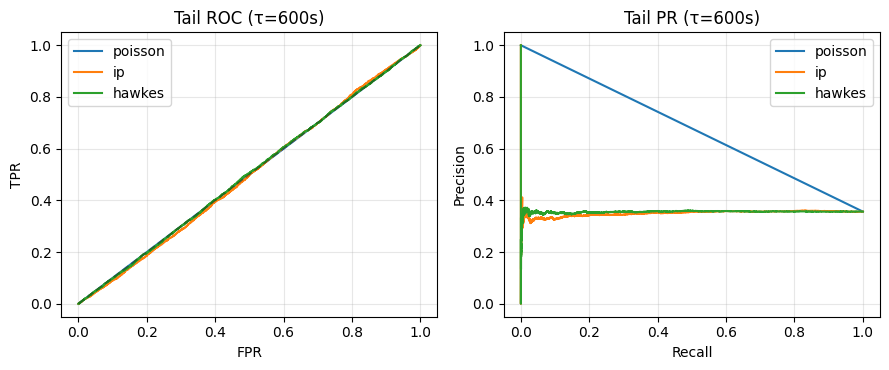

,model,ROC_AUC,PR_AUC,Brier,LogLoss,PosRate
1,ip,0.505738,0.215056,0.204571,0.601267,0.214281
2,hawkes,0.501647,0.213136,0.187163,0.564303,0.214281
0,poisson,0.500000,0.214281,0.168365,0.519575,0.214281


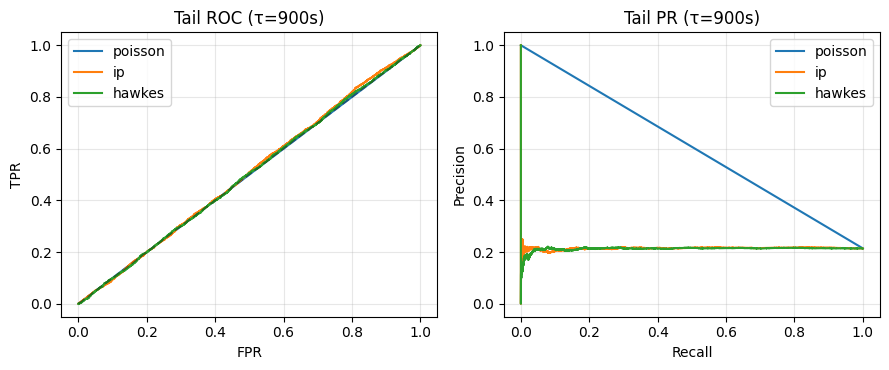

,model,ROC_AUC,PR_AUC,Brier,LogLoss,PosRate
1,ip,0.506715,0.126325,0.168359,0.525669,0.125142
0,poisson,0.500000,0.125142,0.109488,0.377077,0.125142
2,hawkes,0.498997,0.125150,0.126269,0.426526,0.125142


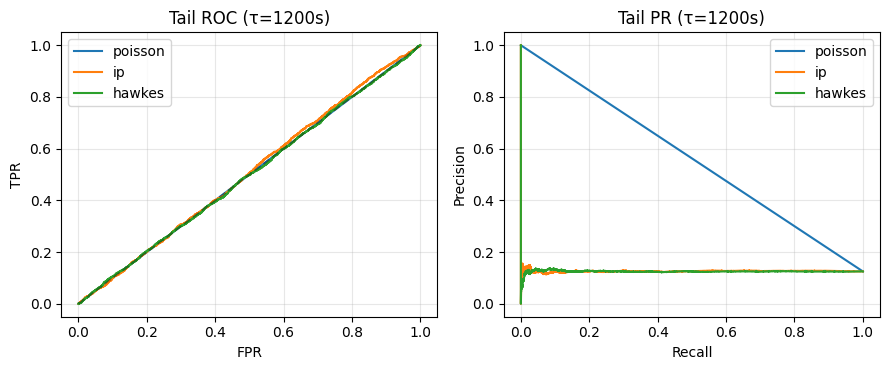

In [59]:


# 1) Make sure your InferenceData objects have ll[var='interval'] (only once)
id_pois   = ensure_ll(id_pois,   "interval")
id_ip     = ensure_ll(id_ip,     "interval")
id_hawkes = ensure_ll(id_hawkes, "interval")
#id_gamma  = ensure_ll(id_gamma,  "interval")  # if you still compare renewals
#id_weib   = ensure_ll(id_weib,   "interval")

# 2) Evaluate — the Hawkes tail probs are now truly conditional and per-draw
res = evaluate_tail_models(
    times, dt, X,
    id_pois=id_pois,
    id_ip=id_ip,
    id_hawkes=id_hawkes,
    taus=(600, 900, 1200)
)

# 3) Inspect metrics and plot curves
for tau in (600, 900, 1200):
    display(res[tau]["metrics"])
    plot_roc_pr(res, tau, title_prefix="Tail ")